In [1]:
import pandas as pd

df = pd.read_csv('D:\Downloads\loan_data.csv')
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [10]:
abs(df.corr()['credit.policy']).sort_values().index[-2]

'inq.last.6mths'

In [8]:
round(df['credit.policy'].corr(df['inq.last.6mths']), 2)

-0.54

In [11]:
from sklearn.model_selection import train_test_split

X = df[['inq.last.6mths']]
Y = df['credit.policy']

X_train, X_test, y_train, y_test = train_test_split(X, Y,
                                                    test_size = 0.2,
                                                    random_state = 42)

In [12]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression().fit(X_train, y_train)

In [14]:
w0 = model1.intercept_
w0.round(2)

array([3.])

In [18]:
w1 = model1.coef_
w1[0][0].round(2) #2d массив

-0.78

$$ P(\text{credit.policy} = 1) = \sigma(3-0.78*\text{inq.last.6mths}) $$

In [22]:
import numpy as np
(1/(1+np.exp(-w0))*100).round(2)

array([95.28])

In [25]:
(1/(1+np.exp(-(w0+w1*3)))*100).round(2)

array([[66.03]])

In [28]:
from sklearn.metrics import log_loss, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, roc_curve

y_pred_proba = model1.predict_proba(X_test)
round(log_loss(y_test, y_pred_proba), 2)

0.35

In [30]:
y_pred = model1.predict(X_test)
confusion_matrix(y_test, y_pred)

array([[ 213,  159],
       [  32, 1512]], dtype=int64)

In [32]:
round(accuracy_score(y_test, y_pred), 2)

0.9

In [33]:
round(precision_score(y_test, y_pred), 2)

0.9

In [34]:
round(recall_score(y_test, y_pred), 2)

0.98

In [35]:
round(f1_score(y_test, y_pred), 2)

0.94

In [39]:
round(roc_auc_score(y_test, y_pred_proba[:, 1]), 2)

0.8

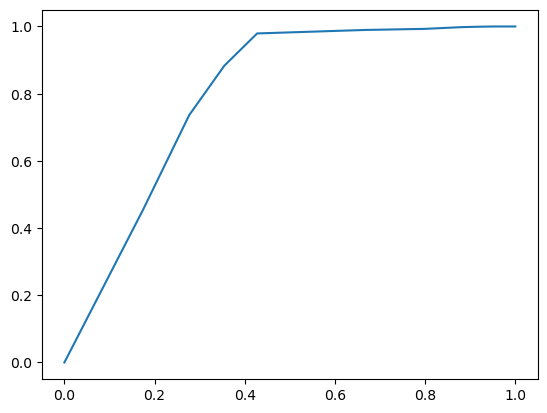

In [43]:
import matplotlib.pyplot as plt
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])

plt.plot(fpr, tpr)